### Run with Transformer

In [174]:
from transformers import pipeline
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2

Device set to use cuda:0


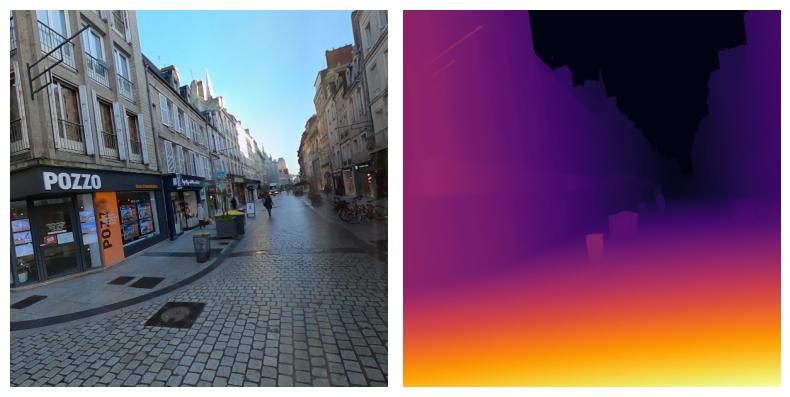

In [ ]:
# 1️⃣ Image-Pfad anpassen
# image_path = f"examples/tests/test2.png"
# image_path = f"examples/out_cc6b8656-d52e-42d1-ab10-542588c9f9f0/img_cc6b8656-d52e-42d1-ab10-542588c9f9f0_260.png"
image_path = f"examples/out_6f34a62d-c8be-429d-b266-b1aca354ae1d/img_6f34a62d-c8be-429d-b266-b1aca354ae1d_40.png"
# image_path = f"examples/out_61efb4ce-cdf2-4160-aaf6-f5bca9c7e247\img_61efb4ce-cdf2-4160-aaf6-f5bca9c7e247_220.png"
# image_path = f"examples/out_61efb4ce-cdf2-4160-aaf6-f5bca9c7e247/img_61efb4ce-cdf2-4160-aaf6-f5bca9c7e247_280.png"
# image_path = f"examples/out_61efb4ce-cdf2-4160-aaf6-f5bca9c7e247/img_61efb4ce-cdf2-4160-aaf6-f5bca9c7e247_300.png"
# image_path = f"examples/out_2ad5a6fe-14bb-4f07-8ee5-780c7e068fee/img_2ad5a6fe-14bb-4f07-8ee5-780c7e068fee_160.png"




image_path = f"examples/out2_cc6b8656-d52e-42d1-ab10-542588c9f9f0/img_cc6b8656-d52e-42d1-ab10-542588c9f9f0_0.png"
image_path = f"examples/out2_cc6b8656-d52e-42d1-ab10-542588c9f9f0/img_cc6b8656-d52e-42d1-ab10-542588c9f9f0_20.png"
image_path = f"examples/out2_cc6b8656-d52e-42d1-ab10-542588c9f9f0/img_cc6b8656-d52e-42d1-ab10-542588c9f9f0_40.png"
image_path = f"examples/out2_cc6b8656-d52e-42d1-ab10-542588c9f9f0/img_cc6b8656-d52e-42d1-ab10-542588c9f9f0_60.png"
image_path = f"examples/out2_cc6b8656-d52e-42d1-ab10-542588c9f9f0/img_cc6b8656-d52e-42d1-ab10-542588c9f9f0_80.png"
image_path = f"examples/out2_cc6b8656-d52e-42d1-ab10-542588c9f9f0/img_cc6b8656-d52e-42d1-ab10-542588c9f9f0_100.png"
image_path = f"examples/out2_cc6b8656-d52e-42d1-ab10-542588c9f9f0/img_cc6b8656-d52e-42d1-ab10-542588c9f9f0_120.png"
image_path = f"examples/out2_cc6b8656-d52e-42d1-ab10-542588c9f9f0/img_cc6b8656-d52e-42d1-ab10-542588c9f9f0_140.png"
image_path = f"examples/out2_cc6b8656-d52e-42d1-ab10-542588c9f9f0/img_cc6b8656-d52e-42d1-ab10-542588c9f9f0_160.png"
image_path = f"examples/out2_cc6b8656-d52e-42d1-ab10-542588c9f9f0/img_cc6b8656-d52e-42d1-ab10-542588c9f9f0_180.png"
image_path = f"examples/out2_cc6b8656-d52e-42d1-ab10-542588c9f9f0/img_cc6b8656-d52e-42d1-ab10-542588c9f9f0_200.png"
image_path = f"examples/out2_cc6b8656-d52e-42d1-ab10-542588c9f9f0/img_cc6b8656-d52e-42d1-ab10-542588c9f9f0_220.png"
image_path = f"examples/out2_cc6b8656-d52e-42d1-ab10-542588c9f9f0/img_cc6b8656-d52e-42d1-ab10-542588c9f9f0_240.png"

image = Image.open(image_path)

# 2️⃣ Depth-Estimation Pipeline
pipe = pipeline(task="depth-estimation", model="depth-anything/Depth-Anything-V2-Small-hf")

# 3️⃣ Depth berechnen
output = pipe(image)
depth_map = output["depth"]

# 4️⃣ Depth visualisieren
depth_norm = (depth_map - np.min(depth_map)) / (np.max(depth_map) - np.min(depth_map))
depth_vis = (depth_norm * 255).astype(np.uint8)

plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
plt.imshow(image)
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(depth_vis, cmap="inferno")
plt.axis("off")
plt.tight_layout()
plt.show()


In [183]:
import shutil


img_name = "2ad5a6fe-14bb-4f07-8ee5-780c7e068fee"

input_path = f"examples/out_{img_name}"             # fp to folder
outdir_name = "results"                             # Name of general output directory
outdir = f"{outdir_name}/{img_name}"                # fp to output directory of folder


if os.path.exists(outdir):
    shutil.rmtree(outdir)    
os.makedirs(outdir, exist_ok=True)




# ---- depth analysis ----
dist_list = np.array([])
mean_center_depth  = np.array([])


if os.path.isdir(input_path):
    files = [f for f in os.listdir(input_path) if os.path.isfile(os.path.join(input_path, f))]
    region_ratio = 0.4      # Area around image center for mean depth anaylsis
    
    # Filter for relevant images (street) 
    for img_fp in files:   
        base = os.path.basename(img_fp)
        name, _ = os.path.splitext(base)
        angle_str = name.split("_")[-1]
        print(angle_str)

0
100
120
140
160
180
20
200
220
240
260
280
300
320
340
40
60
80


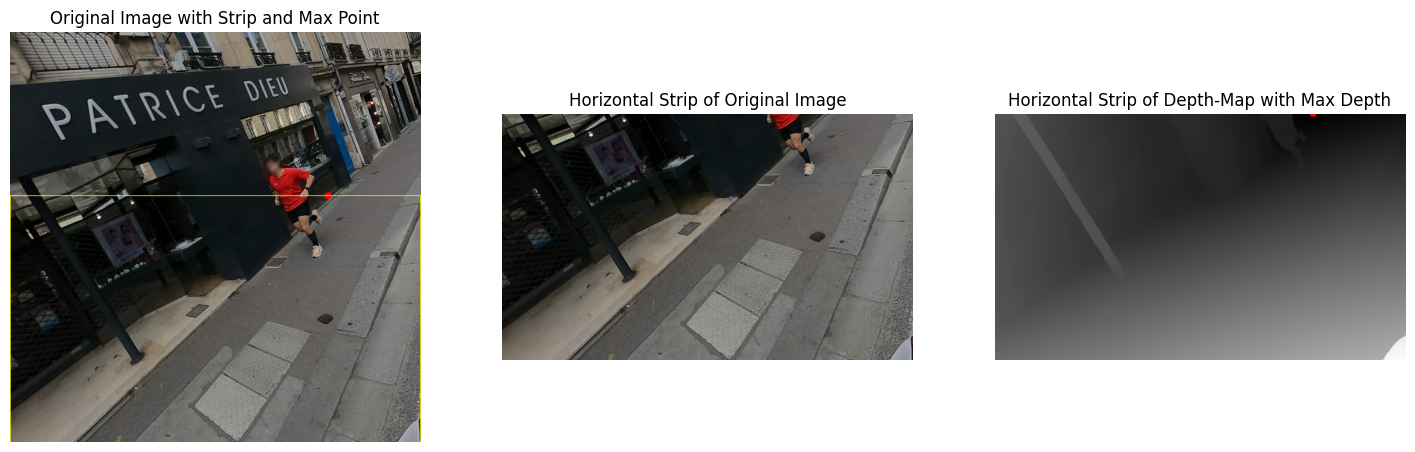

In [176]:
# Depth-Map & Originalbild als NumPy
depth_map_np = np.array(depth_map)
orig_img_np = np.array(image.convert("RGB"))

H, W = depth_map_np.shape
orig_h, orig_w = orig_img_np.shape[:2]

# # Streifen-Einstellungen (um mitte)
# y_ratio = 0.5           # vertical position (0: up, 1: down)
# strip_height_ratio = 0.25  # height of strip

# Streifen-Einstellungen (boden bis mitte)
y_ratio = 1           # vertical position (0: up, 1: down)
strip_height_ratio = 1.2  # height of strip

# Streifen in Depth-Map
y_center = int(H * y_ratio)
strip_h = max(5, int(H * strip_height_ratio))
y_start = max(0, y_center - strip_h // 2)
y_end = min(H, y_center + strip_h // 2)
depth_strip = depth_map_np[y_start:y_end, :]

# Streifen im Originalbild
y_start_orig = int(orig_h * y_ratio - orig_h * strip_height_ratio / 2)
y_end_orig = int(orig_h * y_ratio + orig_h * strip_height_ratio / 2)
orig_strip = orig_img_np[y_start_orig:y_end_orig, :, :].copy()

# Maximalpunkt im Streifen
y_strip, x_strip = np.unravel_index(np.argmin(depth_strip, axis=None), depth_strip.shape)
y_depth = y_start + y_strip
x_depth = x_strip

# Depth-Streifen für Visualisierung vorbereiten
vis_map_strip = ((depth_strip - depth_strip.min()) / (depth_strip.max() - depth_strip.min()) * 255).astype(np.uint8)
vis_depth_rgb_strip = cv2.cvtColor(vis_map_strip, cv2.COLOR_GRAY2RGB)

# Marker auf Depth-Streifen (erstfundener Punkt)
cv2.circle(vis_depth_rgb_strip, (x_strip, y_strip), radius=5, color=(255,0,0), thickness=-1)

# Marker auf Originalbild (erstfundener Punkt)
x_orig = int(x_depth * orig_w / W)
y_in_strip_orig = int((y_strip / strip_h) * (y_end_orig - y_start_orig)) + y_start_orig
orig_img_marked = orig_img_np.copy()
cv2.circle(orig_img_marked, (x_orig, y_in_strip_orig), radius=5, color=(255,0,0), thickness=-1)

# Streifen als Rechteck markieren
cv2.rectangle(orig_img_marked, (0, y_start_orig), (orig_w-1, y_end_orig), color=(255,255,0), thickness=1)

# Ausgabe

plt.figure(figsize=(18,12))
plt.subplot(1,3,1)
plt.imshow(orig_img_marked)
plt.title("Original Image with Strip and Max Point")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(orig_strip)
plt.title("Horizontal Strip of Original Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(vis_depth_rgb_strip)
plt.title("Horizontal Strip of Depth-Map with Max Depth")
plt.axis("off")
plt.show()

Anzahl der Punkte mit maximaler Tiefe im Streifen: 3
Mittelpunkt aller Punkte im Streifen-Koordinatensystem: (x=465, y=0)


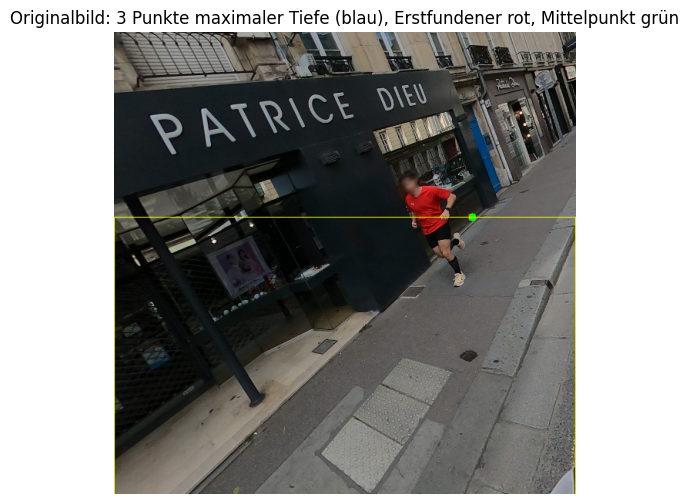

In [177]:
# Alle Punkte mit gleicher Tiefe (Toleranz für Float)
tolerance = 1e-5
ys, xs = np.where(np.abs(depth_strip - depth_strip[y_strip, x_strip]) < tolerance)
num_points = len(xs)
print(f"Anzahl der Punkte mit maximaler Tiefe im Streifen: {num_points}")

# Mittelpunkt berechnen
center_x = int(np.mean(xs))
center_y = int(np.mean(ys))
print(f"Mittelpunkt aller Punkte im Streifen-Koordinatensystem: (x={center_x}, y={center_y})")

# Originalbild kopieren
orig_img_marked = orig_img_np.copy()

# Alle Punkte auf Originalbild markieren (blau)
for y_pt, x_pt in zip(ys, xs):
    x_orig = int(x_pt * orig_w / W)
    y_orig = int((y_pt / strip_h) * (y_end_orig - y_start_orig)) + y_start_orig
    cv2.circle(orig_img_marked, (x_orig, y_orig), radius=3, color=(0,0,255), thickness=-1)

# Erstfundener Punkt (rot)
x_first_orig = int(x_strip * orig_w / W)
y_first_orig = int((y_strip / strip_h) * (y_end_orig - y_start_orig)) + y_start_orig
cv2.circle(orig_img_marked, (x_first_orig, y_first_orig), radius=5, color=(255,0,0), thickness=-1)

# Mittelpunkt (grün)
x_center_orig = int(center_x * orig_w / W)
y_center_orig = int((center_y / strip_h) * (y_end_orig - y_start_orig)) + y_start_orig
cv2.circle(orig_img_marked, (x_center_orig, y_center_orig), radius=5, color=(0,255,0), thickness=-1)

# Streifen als Rechteck markieren
cv2.rectangle(orig_img_marked, (0, y_start_orig), (orig_w-1, y_end_orig), color=(255,255,0), thickness=1)

# Ausgabe
plt.figure(figsize=(10,6))
plt.imshow(orig_img_marked)
plt.title(f"Originalbild: {num_points} Punkte maximaler Tiefe (blau), Erstfundener rot, Mittelpunkt grün")
plt.axis("off")
plt.show()


In [178]:
center_x_img = orig_w // 2
center_y_img = orig_h // 2

# Mittelpunkt der maximalen Tiefe (bereits in x_orig, y_orig)
max_depth_point = np.array([x_orig, y_orig])
image_center = np.array([center_x_img, center_y_img])

# Distanz (euklidisch)
distance = np.linalg.norm(max_depth_point - image_center)
print(f"Bildmittelpunkt: ({center_x_img}, {center_y_img})")
print(f"Maximaler Tiefe Mittelpunkt: ({x_orig}, {y_orig})")
print(f"Euklidische Distanz zum Bildmittelpunkt: {distance:.2f} Pixel")


Bildmittelpunkt: (300, 300)
Maximaler Tiefe Mittelpunkt: (466, 240)
Euklidische Distanz zum Bildmittelpunkt: 176.51 Pixel


In [179]:
depth_norm_value = depth_norm[y_depth, x_depth]
print(f"Normalisierte Tiefe (0–1): {depth_norm_value}")
print(f"Normalisierte Tiefe (0–255): {int(depth_norm_value * 255)}")

Normalisierte Tiefe (0–1): 0.11764705882352941
Normalisierte Tiefe (0–255): 30


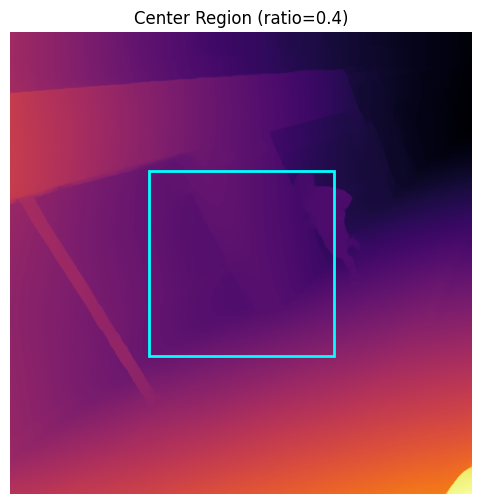

In [180]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

def visualize_center_region(depth_map_np, region_ratio=0.3, orig_image_np=None, cmap="inferno"):

    H, W = depth_map_np.shape

    # Rechteck-Koordinaten
    region_h = int(H * region_ratio)
    region_w = int(W * region_ratio)
    center_y = H // 2
    center_x = W // 2

    y_start = max(0, center_y - region_h // 2)
    y_end = min(H, center_y + region_h // 2)
    x_start = max(0, center_x - region_w // 2)
    x_end = min(W, center_x + region_w // 2)

    # Depth-Map normalisieren für die Darstellung
    depth_norm = (depth_map_np - depth_map_np.min()) / (depth_map_np.max() - depth_map_np.min())

    orig_image_np = None
    if orig_image_np is not None:
        # Optional: Originalbild anzeigen und Rechteck darüberlegen
        plt.figure(figsize=(8, 6))
        plt.imshow(orig_image_np)
        rect_color = (1, 1, 0)  # Gelb
    else:
        # Depth-Map anzeigen
        plt.figure(figsize=(8, 6))
        plt.imshow(depth_norm, cmap=cmap)
        rect_color = "cyan"

    # Rechteck aufzeichnen
    plt.gca().add_patch(
        plt.Rectangle(
            (x_start, y_start),
            region_w,
            region_h,
            edgecolor=rect_color,
            facecolor="none",
            linewidth=2
        )
    )

    plt.title(f"Center Region (ratio={region_ratio})")
    plt.axis("off")
    plt.show()

    # Rückgabe der Koordinaten falls nötig
    return (y_start, y_end, x_start, x_end)


y_start, y_end, x_start, x_end = visualize_center_region(
    depth_map_np,
    region_ratio=0.4,
    orig_image_np=orig_img_np,  # Optional
    cmap="inferno"
)

In [181]:
import shutil


img_name = "2ad5a6fe-14bb-4f07-8ee5-780c7e068fee"

input_path = f"examples/out_{img_name}"             # fp to folder
outdir_name = "results"                             # Name of general output directory
outdir = f"{outdir_name}/{img_name}"                # fp to output directory of folder


if os.path.exists(outdir):
    shutil.rmtree(outdir)    
os.makedirs(outdir, exist_ok=True)




# ---- depth analysis ----
dist_list = np.array([])
mean_center_depth  = np.array([])


if os.path.isdir(input_path):
    files = [f for f in os.listdir(input_path) if os.path.isfile(os.path.join(input_path, f))]
    region_ratio = 0.4      # Area around image center for mean depth anaylsis
    
    # Filter for relevant images (street) 
    for img_fp in files:   
        base = os.path.basename(img_fp)
        name, _ = os.path.splitext(base)
        angle_str = name.split("_")[-1]
        print(angle_str)

0
100
120
140
160
180
20
200
220
240
260
280
300
320
340
40
60
80
